<a href="https://colab.research.google.com/github/HakimHamri/MLPROJECT-GP12/blob/main/MLGP_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
df = pd.read_csv('/content/car_prediction_data.csv')
display(df.head())

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Descriptive Statistics
print("--- DESCRIPTIVE STATISTICS ---")
print(df.describe(include='all'))

# Check for missing values
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# Categorical column value counts
print("\n--- CATEGORICAL VALUE COUNTS ---")
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    print(f"\n{col}:")
    print(df[col].value_counts())

--- DESCRIPTIVE STATISTICS ---
       Car_Name         Year  Selling_Price  Present_Price     Kms_Driven  \
count       301   301.000000     301.000000     301.000000     301.000000   
unique       98          NaN            NaN            NaN            NaN   
top        city          NaN            NaN            NaN            NaN   
freq         26          NaN            NaN            NaN            NaN   
mean        NaN  2013.627907       4.661296       7.628472   36947.205980   
std         NaN     2.891554       5.082812       8.644115   38886.883882   
min         NaN  2003.000000       0.100000       0.320000     500.000000   
25%         NaN  2012.000000       0.900000       1.200000   15000.000000   
50%         NaN  2014.000000       3.600000       6.400000   32000.000000   
75%         NaN  2016.000000       6.000000       9.900000   48767.000000   
max         NaN  2018.000000      35.000000      92.600000  500000.000000   

       Fuel_Type Seller_Type Transmission   

In [ ]:
sns.set_theme(style="whitegrid")

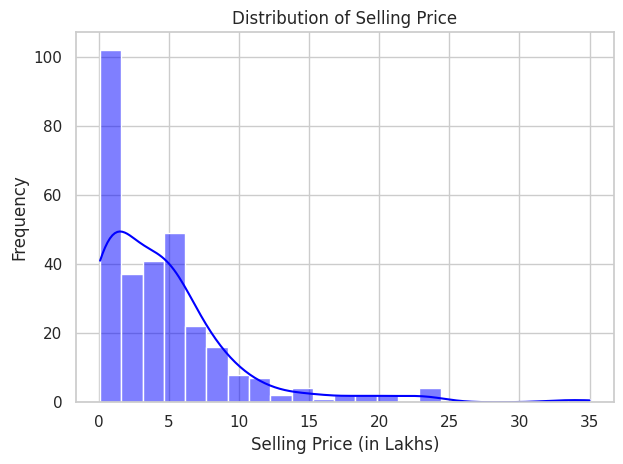

In [ ]:
# 1. Distribution of Selling Price
plt.clf()
sns.histplot(df['Selling_Price'], kde=True, color='blue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('selling_price_distribution.png')

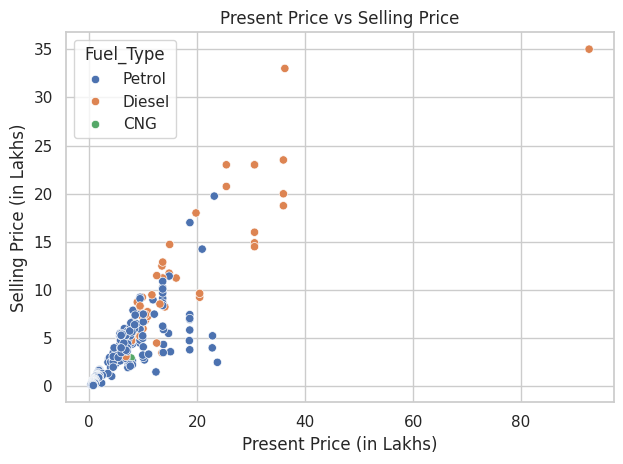

In [ ]:
# 2. Present Price vs Selling Price
plt.clf()
sns.scatterplot(x='Present_Price', y='Selling_Price', hue='Fuel_Type', data=df)
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price (in Lakhs)')
plt.ylabel('Selling Price (in Lakhs)')
plt.tight_layout()
plt.savefig('present_vs_selling_price.png')

<Figure size 640x480 with 0 Axes>

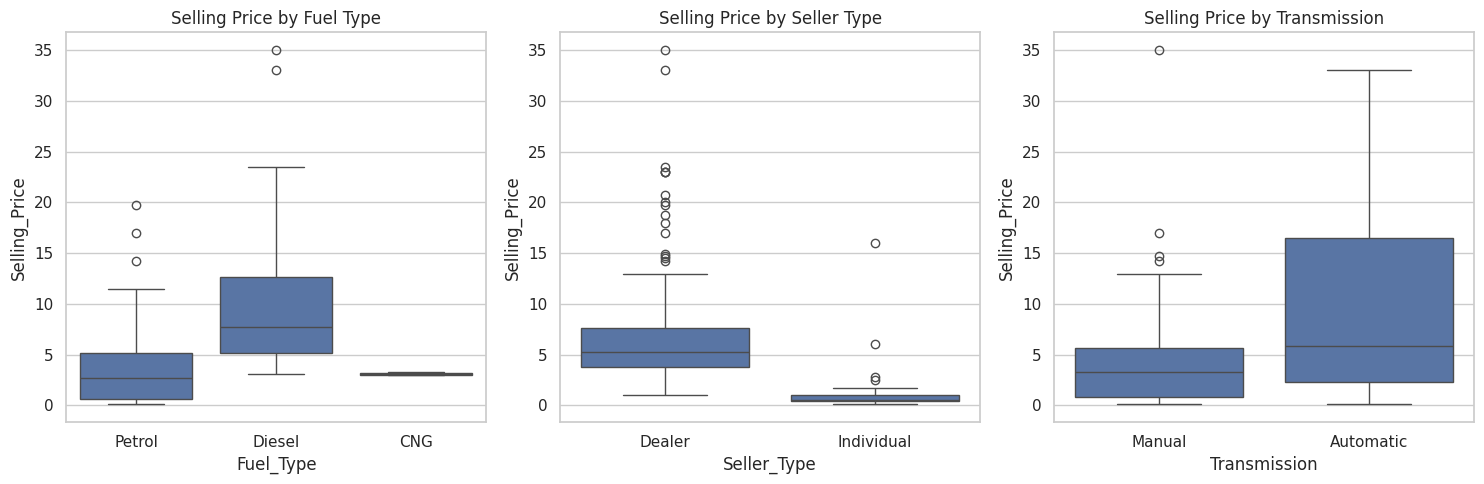

In [ ]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, ax=axes[0])
axes[0].set_title('Selling Price by Fuel Type')
sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, ax=axes[1])
axes[1].set_title('Selling Price by Seller Type')
sns.boxplot(x='Transmission', y='Selling_Price', data=df, ax=axes[2])
axes[2].set_title('Selling Price by Transmission')
plt.tight_layout()
plt.savefig('categorical_vs_selling_price.png')


Plots generated successfully!


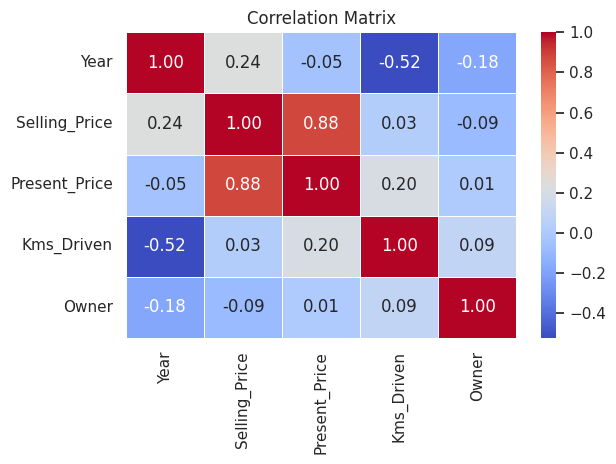

In [ ]:
# 4. Correlation Matrix
plt.clf()
# select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')

print("\nPlots generated successfully!")

SVM

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Remove Car_Name if it exists
if "Car_Name" in df.columns:
    df = df.drop("Car_Name", axis=1)

# Encode categorical variables
label = LabelEncoder()

df["Fuel_Type"] = label.fit_transform(df["Fuel_Type"])
df["Seller_Type"] = label.fit_transform(df["Seller_Type"])
df["Transmission"] = label.fit_transform(df["Transmission"])

# Features and Target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
svm = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)

svm.fit(X_train, y_train)

SVR(C=100, gamma=0.1)

In [ ]:
y_pred = svm.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.46291596931884305
MSE : 0.526612480640072
RMSE: 0.7256807015761629
R2 Score: 0.977139174385776


In [ ]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result.head(10))

   Actual  Predicted
0    0.35   0.624667
1   10.11  10.279576
2    4.95   5.085480
3    0.15  -0.123901
4    6.95   7.847004
5    7.45   6.394700
6    1.10   1.020600
7    0.50   0.568262
8    0.45   0.409541
9    6.00   6.889272


Best parameters found: {'regressor__C': 100, 'regressor__epsilon': 0.1, 'regressor__gamma': 0.01}
Train R2: 0.9737
Test R2: 0.9482
Train MAE: 0.5005
Test MAE: 0.6796
Train RMSE: 0.8338
Test RMSE: 1.0918
SVR plot saved successfully.


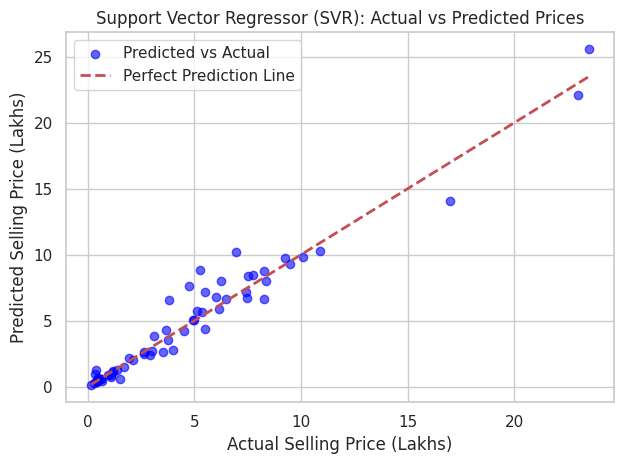

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop Car_Name as it has too many unique values and could cause overfitting/sparse matrix issues
df = df.drop(columns=['Car_Name'], errors='ignore')

# Feature Engineering: Age of car
if 'Year' in df.columns:
    df['Car_Age'] = 2026 - df['Year']
    df = df.drop(columns=['Year'])

# Define features and target
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

# Identify numerical and categorical features
numerical_features = ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Create a pipeline with preprocessor and SVR
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'regressor__C': [0.1, 1, 10, 100, 1000],
    'regressor__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'regressor__epsilon': [0.01, 0.1, 0.2, 0.5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("Best parameters found:", grid_search.best_params_)

# Predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Evaluation metrics
metrics = {
    'Train R2': r2_score(y_train, y_pred_train),
    'Test R2': r2_score(y_test, y_pred_test),
    'Train MAE': mean_absolute_error(y_train, y_pred_train),
    'Test MAE': mean_absolute_error(y_test, y_pred_test),
    'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
}

for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# Plotting Actual vs Predicted
plt.clf()
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Support Vector Regressor (SVR): Actual vs Predicted Prices')
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.legend()
plt.tight_layout()
plt.savefig('svr_actual_vs_predicted.png')

print("SVR plot saved successfully.")

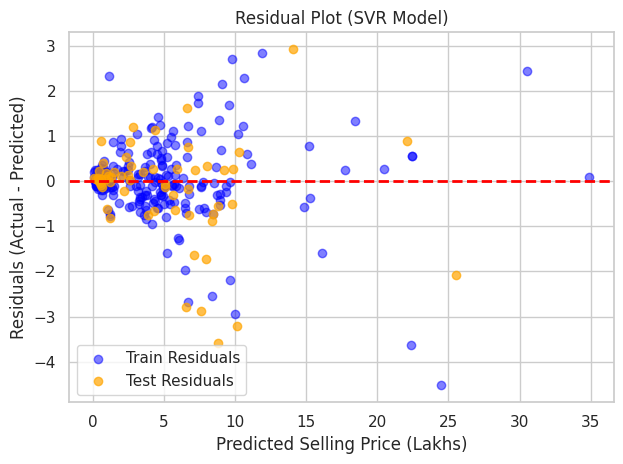

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

# 1. Load and preprocess data
df = df.drop(columns=['Car_Name'], errors='ignore')
if 'Year' in df.columns:
    df['Car_Age'] = 2026 - df['Year']
    df = df.drop(columns=['Year'], errors='ignore')

X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

numerical_features = ['Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# 2. Instantiate pipeline with optimal hyperparameters discovered during grid search
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(C=100, epsilon=0.1, gamma=0.01))
])

# 3. Partition data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# 4. Generate Predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# 5. Compute Residuals (Actual Value - Predicted Value)
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

# 6. Plotting
plt.scatter(y_pred_train, residuals_train, color='blue', alpha=0.5, label='Train Residuals')
plt.scatter(y_pred_test, residuals_test, color='orange', alpha=0.7, label='Test Residuals')
plt.axhline(y=0, color='red', linestyle='--', lw=2)  # Zero error reference line
plt.title('Residual Plot (SVR Model)')
plt.xlabel('Predicted Selling Price (Lakhs)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.tight_layout()
plt.savefig('svr_residual_plot.png')